# Introducción al Aprendizaje Automático — 2do Entregable
## Primer Cuatrimestre 2026

---

**Grupo:** 4

| Integrante | E-mail |
|---|---|
| Gino Mariani | gino_mariani@outlook.com |
| Tomas Martin | martintomasnahuel@gmail.com |

**Título del entregable:** Modelos de clasificación para predicción de riesgo materno

**Enlace al conjunto de datos original:** https://archive.ics.uci.edu/dataset/863/maternal+health+risk

**Enlace alternativo (Kaggle):** https://www.kaggle.com/datasets/csafrit2/maternal-health-risk-data

---
## 1. Resumen

Este trabajo busca predecir el nivel de riesgo materno (alto vs. bajo/medio) a partir de signos vitales de mujeres embarazadas recolectados mediante un sistema IoT en Bangladesh. En el primer entregable exploramos el dataset, identificamos las variables más relevantes (SystolicBP y BS) y detectamos un desbalance de clases al binarizar el target. El objetivo de esta entrega está enfocado en establecer un modelo de referencia (benchmark) basado en conocimiento clínico, entrenar y evaluar un primer modelo de Machine Learning con los dos atributos seleccionados, y desarrollar un segundo modelo más complejo incorporando todas las variables disponibles. Comparamos los modelos usando validación cruzada con Recall como métrica principal, F1-macro como secundaria y AUC-ROC para analizar el trade-off entre umbral de decisión y desempeño.

---
## 2. Librerías y carga del dataset

In [ ]:
# @title
!pip install ucimlrepo -q

In [ ]:
# @title
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, roc_curve, RocCurveDisplay
)
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
RANDOM_STATE = 42

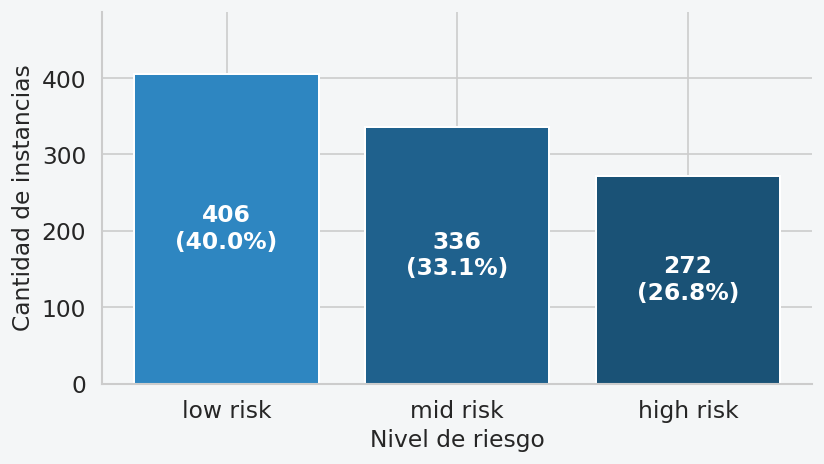

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

order = ['low risk', 'mid risk', 'high risk']
counts = df['RiskLevel'].value_counts()[order]
colors = ['#2e86c1', '#1f618d', '#1a5276']

bars = ax.bar(order, counts.values, color=colors, edgecolor='white', linewidth=1.2)

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='center', fontsize=14, fontweight='bold', color='white')

ax.set_xlabel('Nivel de riesgo', fontsize=14)
ax.set_ylabel('Cantidad de instancias', fontsize=14)
ax.set_ylim(0, max(counts.values) * 1.2)
ax.tick_params(axis='both', labelsize=14)
sns.despine()
plt.tight_layout()
plt.show()

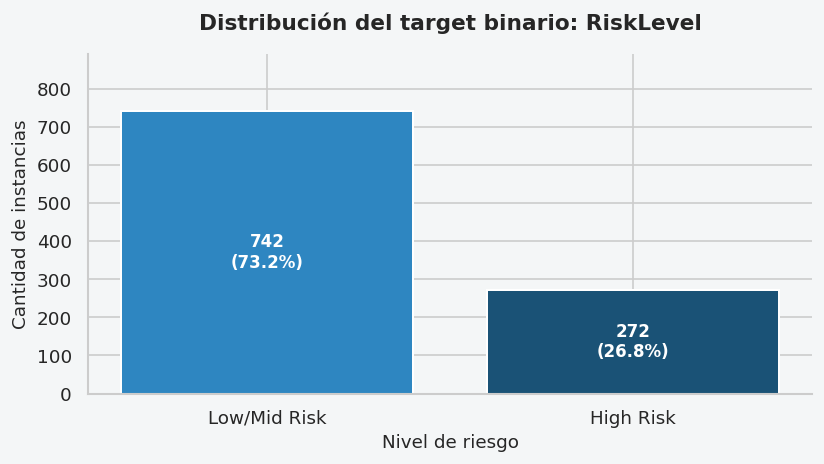

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(7, 4))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

counts_binario = {
    'Low/Mid Risk': df['RiskLevel'].isin(['low risk', 'mid risk']).sum(),
    'High Risk':    (df['RiskLevel'] == 'high risk').sum(),
}
order = ['Low/Mid Risk', 'High Risk']
values = [counts_binario[k] for k in order]
colors = ['#2e86c1', '#1a5276']

bars = ax.bar(order, values, color=colors, edgecolor='white', linewidth=1.2)

for bar, count in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() / 2,
            f'{count}\n({count/len(df)*100:.1f}%)',
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_title('Distribución del target binario: RiskLevel', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Nivel de riesgo', fontsize=11)
ax.set_ylabel('Cantidad de instancias', fontsize=11)
ax.set_ylim(0, max(values) * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

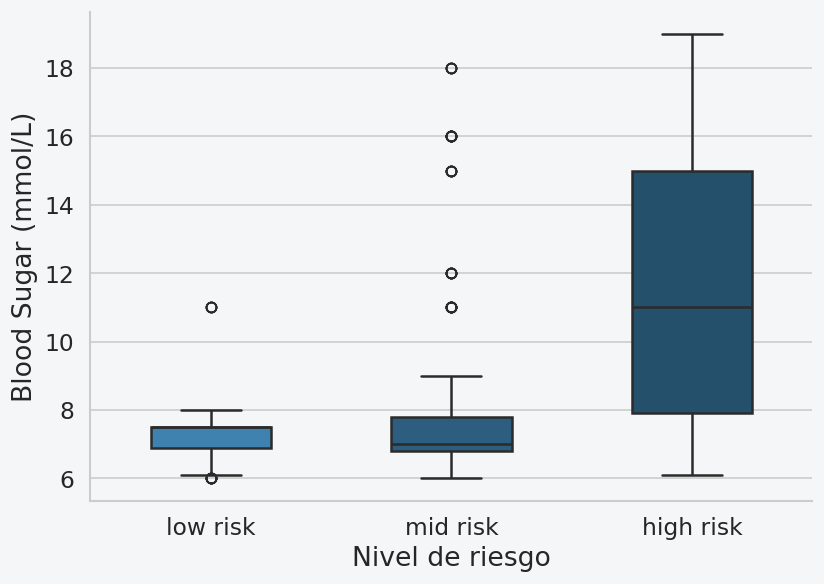

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2e86c1', 'mid risk': '#1f618d', 'high risk': '#1a5276'}

sns.boxplot(data=df, x='RiskLevel', y='BS', hue='RiskLevel',
            order=order, palette=palette, width=0.5, linewidth=1.5,
            ax=ax, legend=False)


ax.set_xlabel('Nivel de riesgo', fontsize=16)
ax.set_ylabel('Blood Sugar (mmol/L)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
sns.despine()
plt.tight_layout()
plt.show()

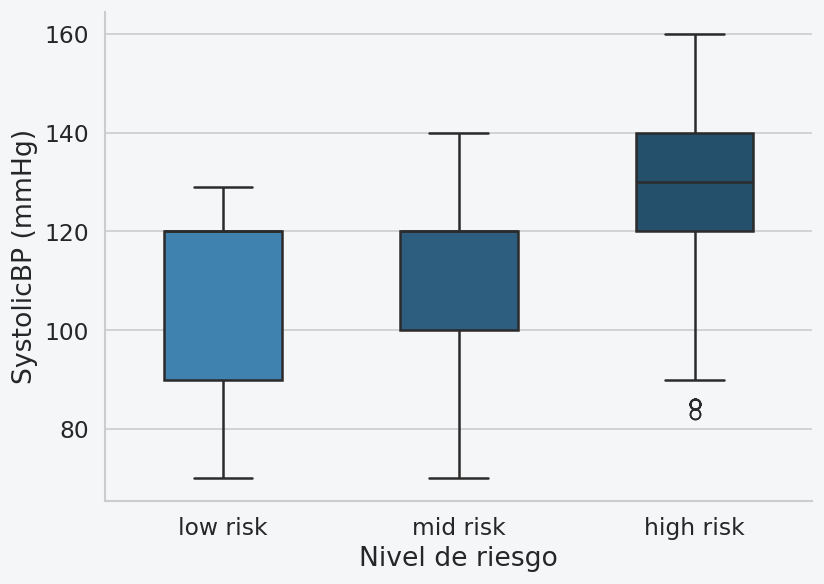

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

order = ['low risk', 'mid risk', 'high risk']
palette = {'low risk': '#2e86c1', 'mid risk': '#1f618d', 'high risk': '#1a5276'}

sns.boxplot(data=df, x='RiskLevel', y='SystolicBP', hue='RiskLevel',
            order=order, palette=palette, width=0.5, linewidth=1.5,
            ax=ax, legend=False)

ax.set_xlabel('Nivel de riesgo', fontsize=16)
ax.set_ylabel('SystolicBP (mmHg)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# @title
try:
    maternal = fetch_ucirepo(id=863)
    df = pd.concat([maternal.data.features, maternal.data.targets], axis=1)
    print('Dataset cargado desde UCI.')
except Exception:
    df = pd.read_csv('Maternal Health Risk Data Set.csv')
    print('Dataset cargado desde archivo local.')

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head()

Dataset cargado desde UCI.
Dimensiones: 1014 filas x 7 columnas


,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,high risk
1,35,140,90,13.0,98.0,70,high risk
2,29,90,70,8.0,100.0,80,high risk
3,30,140,85,7.0,98.0,70,high risk
4,35,120,60,6.1,98.0,76,low risk


---
## 3. Preprocesamiento

### 3a. Binarización del target

Fusionamos `low risk` y `mid risk` en una única clase (0) para priorizar la detección de `high risk` (1), el caso clínicamente más crítico — con mayor riesgo de complicaciones graves durante el embarazo. Esta decisión transforma el problema de 3 clases equilibradas a uno binario con desbalance (742 vs 272 instancias).

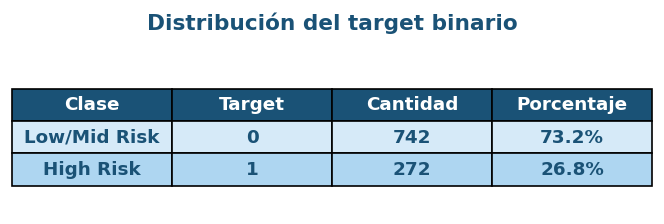

Distribución del target binario:
  low/mid risk (0): 742 (73.2%)
  high risk    (1): 272 (26.8%)


In [ ]:
# @title
df['target'] = df['RiskLevel'].map({'low risk': 0, 'mid risk': 0, 'high risk': 1})

vc = df['target'].value_counts()

# --- Tabla visual ---
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis('off')

data = [
    ['Low/Mid Risk', '0', str(vc[0]), f'{vc[0]/len(df)*100:.1f}%'],
    ['High Risk',    '1', str(vc[1]), f'{vc[1]/len(df)*100:.1f}%'],
]
columns = ['Clase', 'Target', 'Cantidad', 'Porcentaje']

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2)

# Estilo encabezado
for col in range(len(columns)):
    table[0, col].set_facecolor('#1a5276')
    table[0, col].set_text_props(color='white', fontweight='bold')

# Estilo filas
row_colors = ['#d6eaf8', '#aed6f1']  # alternado, variantes del azul
for row in range(1, len(data) + 1):
    for col in range(len(columns)):
        table[row, col].set_facecolor(row_colors[row - 1])
        table[row, col].set_text_props(color='#1a5276', fontweight='bold')

ax.set_title('Distribución del target binario', fontsize=13,
             fontweight='bold', color='#1a5276', pad=20)

plt.tight_layout()
plt.show()

# Print en consola también (opcional, podés borrar si no lo necesitás)
print('Distribución del target binario:')
print(f'  low/mid risk (0): {vc[0]} ({vc[0]/len(df)*100:.1f}%)')
print(f'  high risk    (1): {vc[1]} ({vc[1]/len(df)*100:.1f}%)')

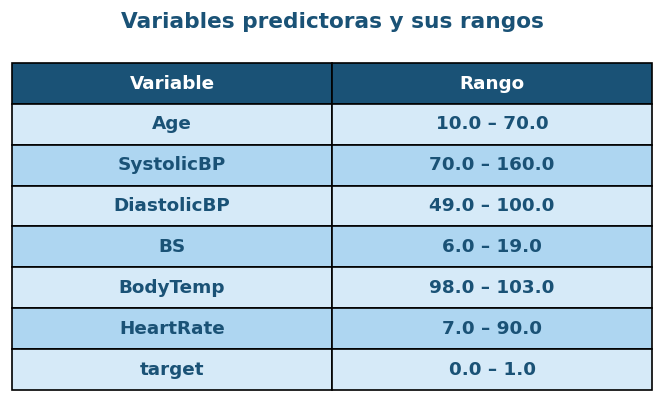

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.axis('off')

variables = [col for col in df.columns if col != 'RiskLevel']
data_tabla = [[var, f'{df[var].min():.1f} – {df[var].max():.1f}'] for var in variables]
columns = ['Variable', 'Rango']

table = ax.table(
    cellText=data_tabla,
    colLabels=columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 2)

for col in range(len(columns)):
    table[0, col].set_facecolor('#1a5276')
    table[0, col].set_text_props(color='white', fontweight='bold')

row_colors = ['#d6eaf8', '#aed6f1']
for row in range(1, len(data_tabla) + 1):
    for col in range(len(columns)):
        table[row, col].set_facecolor(row_colors[(row - 1) % 2])
        table[row, col].set_text_props(color='#1a5276', fontweight='bold')

ax.set_title('Variables predictoras y sus rangos', fontsize=13,
             fontweight='bold', color='#1a5276', pad=20)

plt.tight_layout()
plt.show()

### 3b. Train/Test split estratificado

Dividimos el dataset en 80% entrenamiento y 20% evaluación. El parámetro `stratify=y` garantiza que la proporción de clases (73/27) se mantenga igual en ambos conjuntos. Sin estratificación, por azar el conjunto de test podría quedar con muy pocos casos de `high risk`, haciendo la evaluación final poco representativa.

El **conjunto de test se reserva exclusivamente para la evaluación final** del modelo seleccionado. Toda comparación entre modelos y selección de hiperparámetros se realiza mediante validación cruzada sobre el conjunto de entrenamiento.

In [ ]:
# @title
FEATURES    = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']


X = df[FEATURES]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} instancias  |  high risk: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Test:  {X_test.shape[0]} instancias  |  high risk: {y_test.sum()} ({y_test.mean()*100:.1f}%)')

Train: 811 instancias  |  high risk: 218 (26.9%)
Test:  203 instancias  |  high risk: 54 (26.6%)


### 3c. Manejo del desbalance con `class_weight='balanced'`

Con un desbalance de 73/27, un modelo sin tratamiento tendería a predecir siempre `low/mid risk` para minimizar errores globales, ignorando los casos de `high risk`. Usamos `class_weight='balanced'` en ambos modelos, que calcula automáticamente un peso inversamente proporcional a la frecuencia de cada clase:

$$\text{peso}_c = \frac{n_{\text{total}}}{n_{\text{clases}} \times n_c}$$

Esto hace que cada error en `high risk` pese aproximadamente 2.7 veces más durante el entrenamiento, **sin modificar el dataset original**. Como todo trade-off, esto implica que el modelo puede generar más falsos positivos — es decir, clasificar como `high risk` casos que no lo son — lo cual en un contexto clínico es preferible a no detectar un caso real de alto riesgo.

---
## 4. Benchmark: reglas clínicas manuales

El benchmark es un modelo de referencia que no utiliza aprendizaje automático. Fija un piso mínimo de desempeño contra el cual comparar los modelos de ML.

Lo construimos usando umbrales clínicos estándar definidos por la OMS y guías obstétricas internacionales:
- **SystolicBP ≥ 140 mmHg**: umbral oficial de hipertensión gestacional / preeclampsia
- **BS ≥ 7.8 mmol/L**: umbral de diabetes gestacional

Si cualquiera de estas condiciones se cumple → `high risk`. Caso contrario → `low/mid risk`.

Estos umbrales provienen de literatura médica externa al dataset, lo que garantiza que el benchmark sea completamente independiente del proceso de entrenamiento.

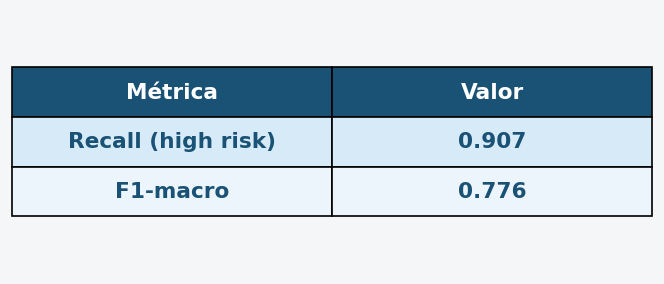

In [ ]:
def benchmark_predict(X):
    return ((X['SystolicBP'] >= 140) | (X['BS'] >= 7.8)).astype(int)

y_bench = benchmark_predict(X_test)

recall_bench = recall_score(y_test, y_bench)
f1_bench     = f1_score(y_test, y_bench, average='macro')

# --- Tabla visual ---
fig, ax = plt.subplots(figsize=(6, 2.5))
ax.axis('off')
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

data = [
    ['Recall (high risk)', f'{recall_bench:.3f}'],
    ['F1-macro',           f'{f1_bench:.3f}'],
]
columns = ['Métrica', 'Valor']

table = ax.table(cellText=data, colLabels=columns, cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1.4, 2.2)

for col in range(len(columns)):
    table[0, col].set_facecolor('#1a5276')
    table[0, col].set_text_props(color='white', fontweight='bold')

row_colors = ['#d6eaf8', '#ebf5fb']
for row in range(1, len(data) + 1):
    for col in range(len(columns)):
        table[row, col].set_facecolor(row_colors[(row - 1) % 2])
        table[row, col].set_text_props(color='#1a5276', fontweight='bold')


plt.tight_layout()
plt.show()

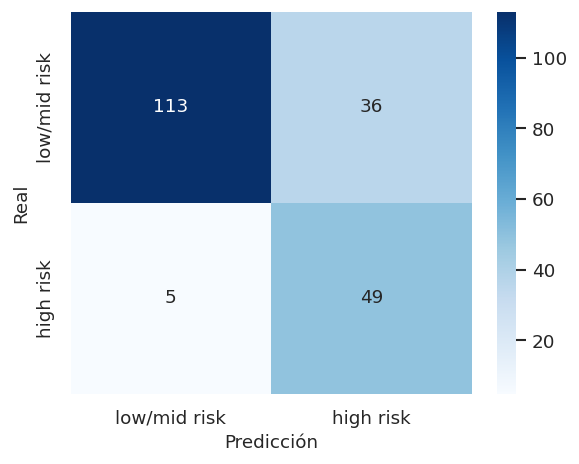

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(5, 4))
cm_bench = confusion_matrix(y_test, y_bench)
sns.heatmap(cm_bench, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low/mid risk', 'high risk'],
            yticklabels=['low/mid risk', 'high risk'], ax=ax)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
plt.tight_layout()
plt.show()

**Interpretación:**

El benchmark obtiene un Recall de `high risk` de {recall_bench:.3f}, detectando la mayoría de los casos gracias a las reglas clínicas. Sin embargo, como observamos en el entregable anterior mediante los boxplots, muchas pacientes de `high risk` tienen SystolicBP entre 120 y 139 mmHg — por debajo del umbral de 140 — y niveles de BS que se solapan con las clases de menor riesgo. Esto limita su capacidad de detección y su F1-macro, justificando la necesidad de modelos de ML capaces de aprender patrones más complejos.

---
## 5. Modelo 1: Árbol de Decisión (6 atributos)

### 5a. Descripción

El primer modelo es un **Árbol de Decisión** entrenado con `SystolicBP` y `BS`, los dos atributos identificados en el entregable anterior como los de mayor poder predictivo. Lo elegimos como primer modelo por su alta interpretabilidad: podemos visualizar exactamente qué reglas aprendió y cómo toma cada decisión. Además, trabajar con solo 2 features nos permite visualizar la frontera de decisión en el plano.

### 5b. Selección de `max_depth`

El hiperparámetro más importante de un árbol es `max_depth`. Un árbol muy profundo puede memorizar el conjunto de entrenamiento (**overfitting**), mientras que uno muy superficial puede ser demasiado simple (**underfitting**).

Para elegir el valor óptimo graficamos el Recall en train y en validación cruzada (k=5) para cada profundidad. Usamos validación cruzada en lugar del test set para evitar tomar decisiones de hiperparámetros basadas en ese conjunto, reservándolo para la evaluación final.

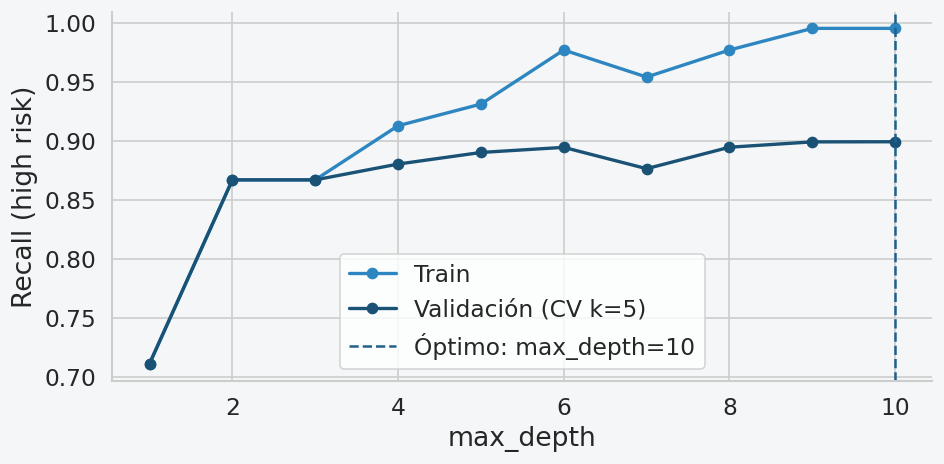

In [ ]:
X_train_m1 = X_train[FEATURES]
X_test_m1  = X_test[FEATURES]

depths = range(1, 11)
recall_train_list, recall_val_list = [], []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
    t.fit(X_train_m1, y_train)
    recall_train_list.append(recall_score(y_train, t.predict(X_train_m1)))
    cv_scores = cross_val_score(t, X_train_m1, y_train, cv=5, scoring='recall')
    recall_val_list.append(cv_scores.mean())

best_depth = depths[np.argmax(recall_val_list)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

ax.plot(depths, recall_train_list, marker='o', label='Train',
        color='#2e86c1', linewidth=2)
ax.plot(depths, recall_val_list,   marker='o', label='Validación (CV k=5)',
        color='#1a5276', linewidth=2)
ax.axvline(x=best_depth, color='#1f618d', linestyle='--',
           label=f'Óptimo: max_depth={best_depth}')

ax.set_xlabel('max_depth', fontsize=16)
ax.set_ylabel('Recall (high risk)', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación del gráfico:**

El gráfico compara el Recall en train con el Recall en validación cruzada para cada valor de `max_depth`. El punto óptimo es aquel donde el Recall de validación es máximo. A partir de ese valor, aunque el Recall de train sigue creciendo — señal de que el árbol memoriza los datos de entrenamiento — el de validación se estanca o empeora, indicando overfitting.

### 5c. Entrenamiento

In [ ]:
# @title
tree_model = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
tree_model.fit(X_train_m1, y_train)
print(f'Árbol de Decisión entrenado con max_depth={best_depth}.')

Árbol de Decisión entrenado con max_depth=10.


### 5d. Visualización del árbol

Una de las grandes ventajas del árbol de decisión es su interpretabilidad: podemos visualizar exactamente las reglas que aprendió. Cada nodo muestra la condición de división, la impureza Gini, la cantidad de muestras y la distribución de clases.

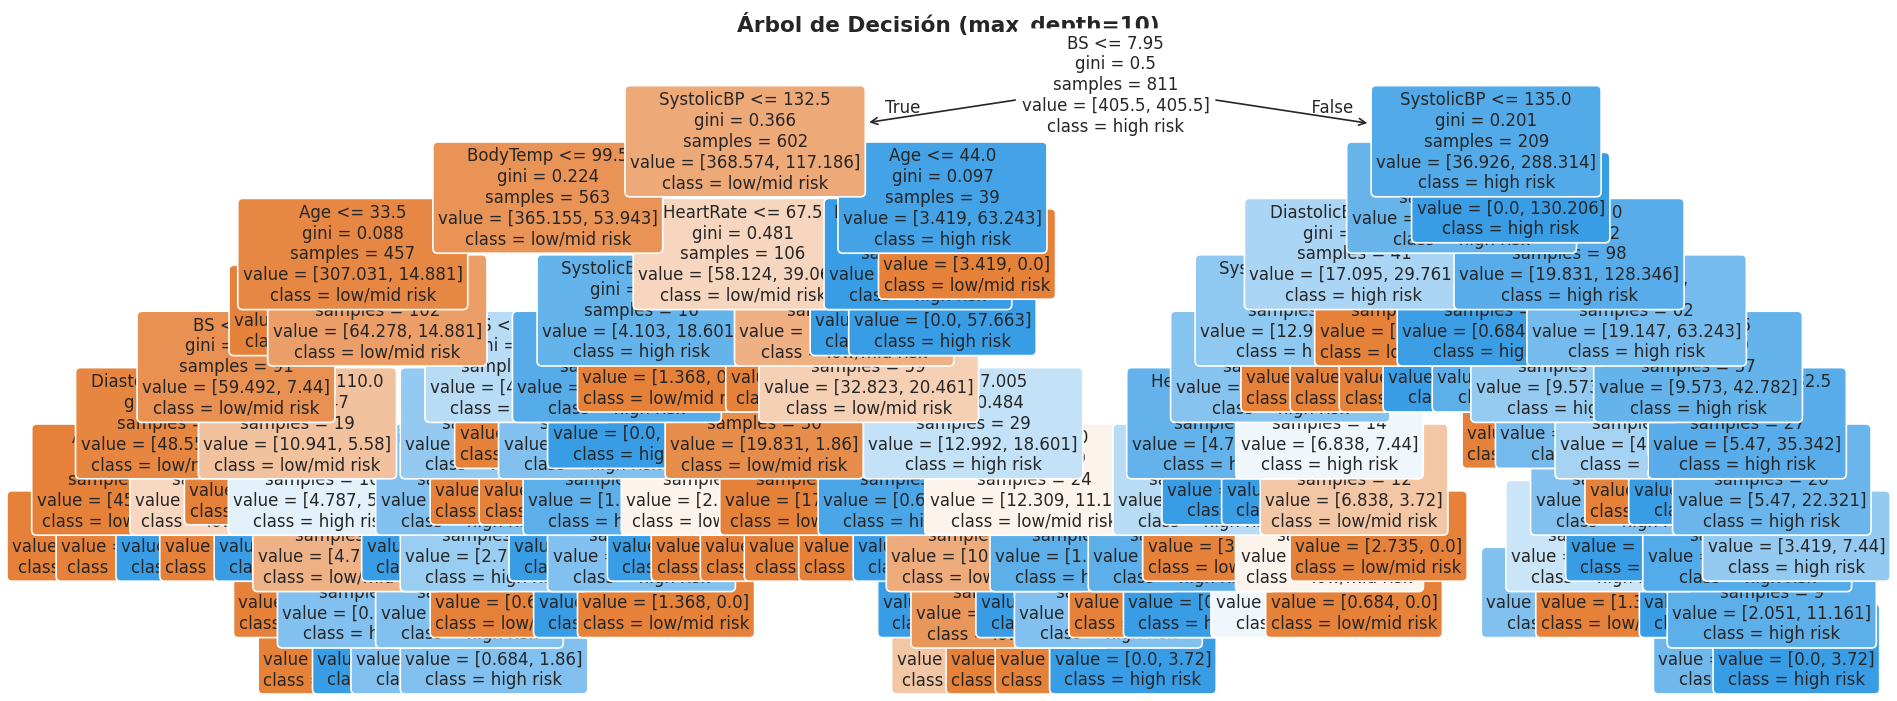

In [ ]:
# @title
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    tree_model,
    feature_names=FEATURES,
    class_names=['low/mid risk', 'high risk'],
    filled=True,
    rounded=True,
    fontsize=10,
    ax=ax
)
ax.set_title(f'Árbol de Decisión (max_depth={best_depth})', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

**Interpretación del árbol:**

El árbol muestra claramente que `BS` y `SystolicBP` son las variables de división en los nodos superiores, confirmando el poder predictivo que identificamos en el entregable anterior. Los nodos más oscuros corresponden a hojas con mayor pureza — es decir, donde la mayoría de las instancias pertenecen a una sola clase. Los nodos más claros indican mayor mezcla de clases, que son los casos donde el modelo tiene más incertidumbre.

### 5e. Métricas (validación cruzada)

=== Modelo 1: Árbol de Decisión (CV k=5) ===
Recall (high risk): 0.899 ± 0.034
F1-macro:           0.912 ± 0.013
AUC-ROC:            0.938 ± 0.013


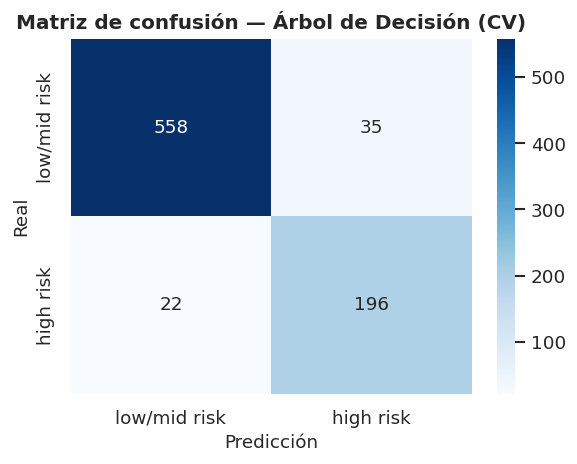

In [ ]:
# Métricas con CV
cv_recall_m1 = cross_val_score(tree_model, X_train_m1, y_train, cv=5, scoring='recall')
cv_f1_m1     = cross_val_score(tree_model, X_train_m1, y_train, cv=5, scoring='f1_macro')
cv_auc_m1    = cross_val_score(tree_model, X_train_m1, y_train, cv=5, scoring='roc_auc')

print('=== Modelo 1: Árbol de Decisión (CV k=5) ===')
print(f'Recall (high risk): {cv_recall_m1.mean():.3f} ± {cv_recall_m1.std():.3f}')
print(f'F1-macro:           {cv_f1_m1.mean():.3f} ± {cv_f1_m1.std():.3f}')
print(f'AUC-ROC:            {cv_auc_m1.mean():.3f} ± {cv_auc_m1.std():.3f}')

# Matriz de confusión con cross_val_predict
y_pred_m1_cv = cross_val_predict(tree_model, X_train_m1, y_train, cv=5)

fig, ax = plt.subplots(figsize=(5, 4))
cm_m1 = confusion_matrix(y_train, y_pred_m1_cv)
sns.heatmap(cm_m1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low/mid risk', 'high risk'],
            yticklabels=['low/mid risk', 'high risk'], ax=ax)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de confusión — Árbol de Decisión (CV)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Modelo 2: Random Forest (6 atributos)

### 6a. Descripción

El segundo modelo es un **Random Forest**, un ensamble de múltiples árboles de decisión. Cada árbol se entrena sobre un subconjunto aleatorio de filas del dataset y, en cada división, solo puede usar **k features aleatorias** de las m totales (siendo k < m). Esto introduce diversidad entre los árboles y reduce la correlación entre ellos. El resultado final es el voto mayoritario de todos los árboles individuales.

Usamos `max_features='sqrt'` (valor por defecto), lo que significa que cada árbol ve √6 ≈ 2 features aleatorias por división. Cuando k = m, el modelo se convierte en Bagging puro y pierde la diversidad que caracteriza a Random Forest.

En este modelo incorporamos las 6 features disponibles: `Age`, `SystolicBP`, `DiastolicBP`, `BS`, `BodyTemp` y `HeartRate`.

### 6b. Optimización de hiperparámetros con GridSearchCV

Usamos `GridSearchCV` con validación cruzada de 5 folds para encontrar la mejor combinación de hiperparámetros, optimizando el **Recall** de `high risk` como métrica principal. Los hiperparámetros explorados son:
- `n_estimators`: cantidad de árboles en el ensamble
- `max_depth`: profundidad máxima de cada árbol
- `min_samples_leaf`: mínimo de muestras requeridas en cada hoja

In [ ]:
# @title
param_grid_m2 = {
    'n_estimators':     [10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    'max_depth':        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'min_samples_leaf': [5, 10, 15, 20]
}

grid_m2 = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    param_grid_m2,
    cv=5,
    scoring='recall',
    n_jobs=-1
)
grid_m2.fit(X_train, y_train)

print('Mejores hiperparámetros:')
print(grid_m2.best_params_)
print(f'\nMejor Recall (CV): {grid_m2.best_score_:.3f}')

Mejores hiperparámetros:
{'max_depth': 6, 'min_samples_leaf': 5, 'n_estimators': 30}

Mejor Recall (CV): 0.908


### 6c. Selección de `n_estimators`

Graficamos cómo evoluciona el Recall en train y en validación cruzada a medida que aumenta el número de árboles, manteniendo fijos los demás hiperparámetros óptimos encontrados. Esto permite visualizar a partir de cuántos árboles el modelo converge.

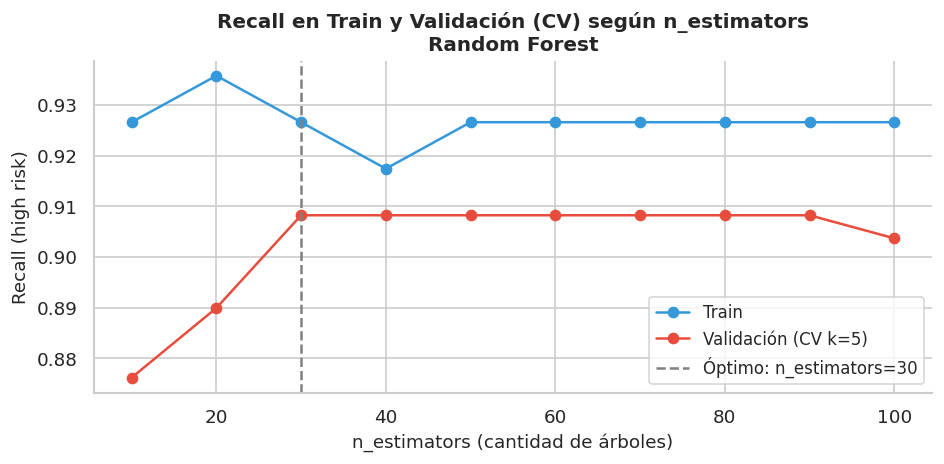

Mejor n_estimators: 30  |  Recall en validación (CV): 0.908


In [ ]:
# @title
best_params_sin_n = {k: v for k, v in grid_m2.best_params_.items() if k != 'n_estimators'}
n_estimators_list = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
recall_train_rf, recall_val_rf = [], []

for n in n_estimators_list:
    rf_tmp = RandomForestClassifier(
        n_estimators=n,
        **best_params_sin_n,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
    rf_tmp.fit(X_train, y_train)
    recall_train_rf.append(recall_score(y_train, rf_tmp.predict(X_train)))
    cv_scores = cross_val_score(rf_tmp, X_train, y_train, cv=5, scoring='recall')
    recall_val_rf.append(cv_scores.mean())

best_n = n_estimators_list[np.argmax(recall_val_rf)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(n_estimators_list, recall_train_rf, marker='o', label='Train',               color='#3498db')
ax.plot(n_estimators_list, recall_val_rf,   marker='o', label='Validación (CV k=5)', color='#e74c3c')
ax.axvline(x=best_n, color='gray', linestyle='--',
           label=f'Óptimo: n_estimators={best_n}')
ax.set_xlabel('n_estimators (cantidad de árboles)', fontsize=11)
ax.set_ylabel('Recall (high risk)', fontsize=11)
ax.set_title('Recall en Train y Validación (CV) según n_estimators\nRandom Forest', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

print(f'Mejor n_estimators: {best_n}  |  Recall en validación (CV): {max(recall_val_rf):.3f}')

**Interpretación:**

A diferencia del árbol de decisión individual, el Random Forest no muestra overfitting severo al aumentar la cantidad de árboles: el Recall de validación converge y se estabiliza a medida que se agregan más árboles. Esto confirma que el mecanismo de ensamble actúa como regulador natural. Elegimos el `n_estimators` donde el Recall de validación es máximo, priorizando el modelo más simple que logra el mejor desempeño.

### 6d. Entrenamiento

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=best_n,
    **best_params_sin_n,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
rf_model.fit(X_train, y_train)
print(f'Random Forest entrenado con n_estimators={best_n} y {best_params_sin_n}.')

Random Forest entrenado con n_estimators=30 y {'max_depth': 6, 'min_samples_leaf': 5}.


### 6e. Métricas (validación cruzada)

In [ ]:
# @title
cv_recall_m2 = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='recall')
cv_f1_m2     = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1_macro')
cv_auc_m2    = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='roc_auc')

print('=== Modelo 2: Random Forest (CV k=5) ===')
print(f'Recall (high risk): {cv_recall_m2.mean():.3f} ± {cv_recall_m2.std():.3f}')
print(f'F1-macro:           {cv_f1_m2.mean():.3f} ± {cv_f1_m2.std():.3f}')
print(f'AUC-ROC:            {cv_auc_m2.mean():.3f} ± {cv_auc_m2.std():.3f}')

=== Modelo 2: Random Forest (CV k=5) ===
Recall (high risk): 0.908 ± 0.032
F1-macro:           0.890 ± 0.030
AUC-ROC:            0.963 ± 0.013


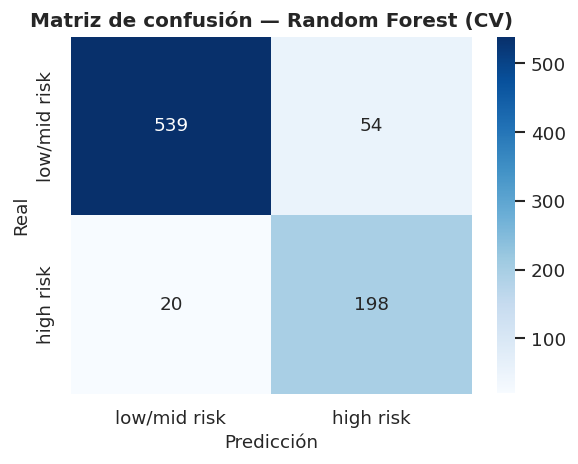

In [ ]:
# Matriz de confusión con cross_val_predict
y_pred_m2_cv = cross_val_predict(rf_model, X_train, y_train, cv=5)

fig, ax = plt.subplots(figsize=(5, 4))
cm_m2 = confusion_matrix(y_train, y_pred_m2_cv)
sns.heatmap(cm_m2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['low/mid risk', 'high risk'],
            yticklabels=['low/mid risk', 'high risk'], ax=ax)
ax.set_xlabel('Predicción', fontsize=11)
ax.set_ylabel('Real', fontsize=11)
ax.set_title('Matriz de confusión — Random Forest (CV)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 6f. Importancia de atributos

El Random Forest calcula automáticamente la importancia de cada feature (`feature_importances_`), definida como la reducción promedio de impureza Gini que aporta cada variable a lo largo de todos los árboles del ensamble. Dado que los árboles de decisión son invariantes a la escala, estos valores son directamente comparables entre features sin necesidad de escalarlas previamente.

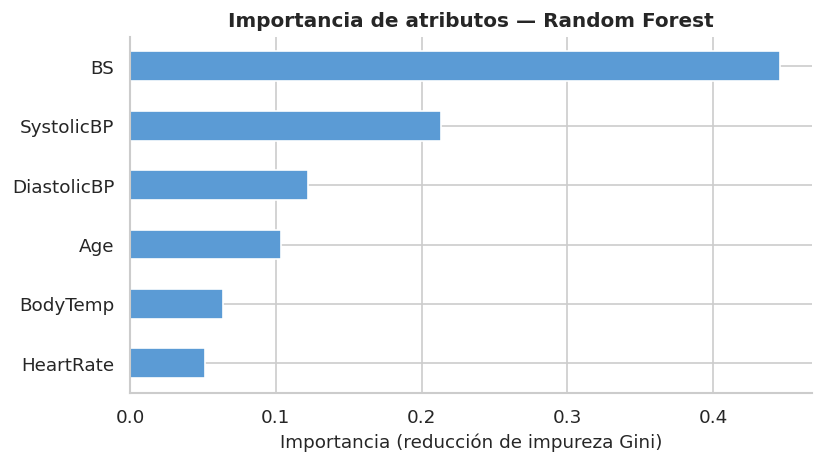

BS             0.4460
SystolicBP     0.2132
DiastolicBP    0.1220
Age            0.1038
BodyTemp       0.0639
HeartRate      0.0510
dtype: float64


In [ ]:
# @title
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importancias.plot(kind='barh', ax=ax, color='#5b9bd5', edgecolor='white')
ax.set_title('Importancia de atributos — Random Forest', fontsize=12, fontweight='bold')
ax.set_xlabel('Importancia (reducción de impureza Gini)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).round(4))

---
## 7. Comparación de modelos

### 7a. Tabla resumen

Comparamos los tres modelos usando métricas de validación cruzada (k=5) para el Árbol de Decisión y Random Forest, y métricas sobre test para el Benchmark (que no tiene proceso de entrenamiento).

In [ ]:
# @title
resultados = pd.DataFrame({
    'Modelo': [
        'Benchmark (reglas clínicas)',
        'Árbol de Decisión (6 features)',
        'Random Forest (6 features)'
    ],
    'Recall high risk': [
        f'{recall_bench:.3f}',
        f'{cv_recall_m1.mean():.3f} ± {cv_recall_m1.std():.3f}',
        f'{cv_recall_m2.mean():.3f} ± {cv_recall_m2.std():.3f}'
    ],
    'F1-macro': [
        f'{f1_bench:.3f}',
        f'{cv_f1_m1.mean():.3f} ± {cv_f1_m1.std():.3f}',
        f'{cv_f1_m2.mean():.3f} ± {cv_f1_m2.std():.3f}'
    ],
    'AUC-ROC': [
        'N/A',
        f'{cv_auc_m1.mean():.3f} ± {cv_auc_m1.std():.3f}',
        f'{cv_auc_m2.mean():.3f} ± {cv_auc_m2.std():.3f}'
    ]
}).set_index('Modelo')

display(resultados)

,Recall high risk,F1-macro,AUC-ROC
Modelo,,,
Benchmark (reglas clínicas),0.907,0.776,N/A
Árbol de Decisión (6 features),0.899 ± 0.034,0.912 ± 0.013,0.938 ± 0.013
Random Forest (6 features),0.908 ± 0.032,0.890 ± 0.030,0.963 ± 0.013


### 7b. Curva ROC y análisis de umbral

La curva ROC muestra el trade-off entre Recall (Tasa de Verdaderos Positivos) y Tasa de Falsos Positivos para todos los umbrales de decisión posibles. Por defecto los modelos clasifican como `high risk` cuando la probabilidad predicha supera 0.5, pero en un contexto clínico puede ser conveniente bajar ese umbral para capturar más casos de `high risk` a costa de más falsas alarmas.

El gráfico de la derecha muestra el trade-off explícito para el modelo seleccionado: al bajar el umbral, el Recall sube pero también sube la Tasa de Falsos Positivos.

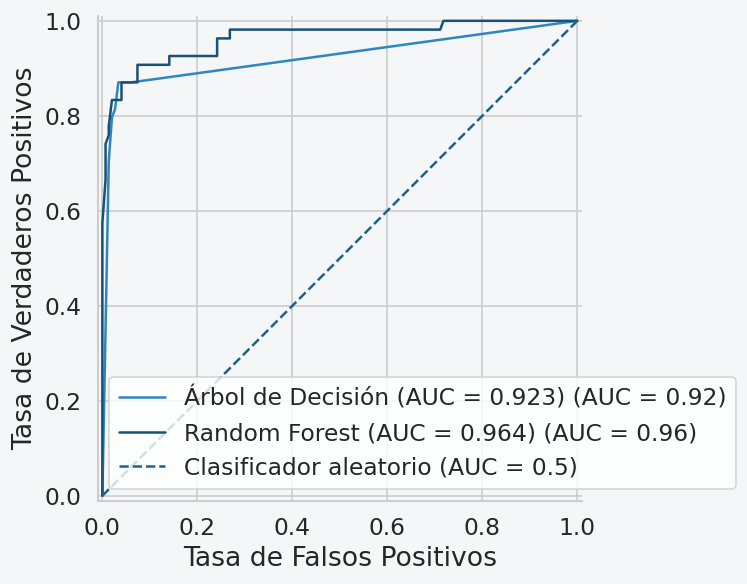

In [ ]:
y_proba_m1 = tree_model.predict_proba(X_test)[:, 1]
y_proba_m2 = rf_model.predict_proba(X_test)[:, 1]

auc_m1_test = roc_auc_score(y_test, y_proba_m1)
auc_m2_test = roc_auc_score(y_test, y_proba_m2)

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

RocCurveDisplay.from_predictions(y_test, y_proba_m1, ax=ax,
    name=f'Árbol de Decisión (AUC = {auc_m1_test:.3f})', color='#2e86c1')
RocCurveDisplay.from_predictions(y_test, y_proba_m2, ax=ax,
    name=f'Random Forest (AUC = {auc_m2_test:.3f})', color='#1a5276')
ax.plot([0, 1], [0, 1], '--', color='#1f618d', label='Clasificador aleatorio (AUC = 0.5)')

ax.set_title('Curva ROC — Comparación de modelos', fontsize=18, fontweight='bold')
ax.legend(fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=16)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

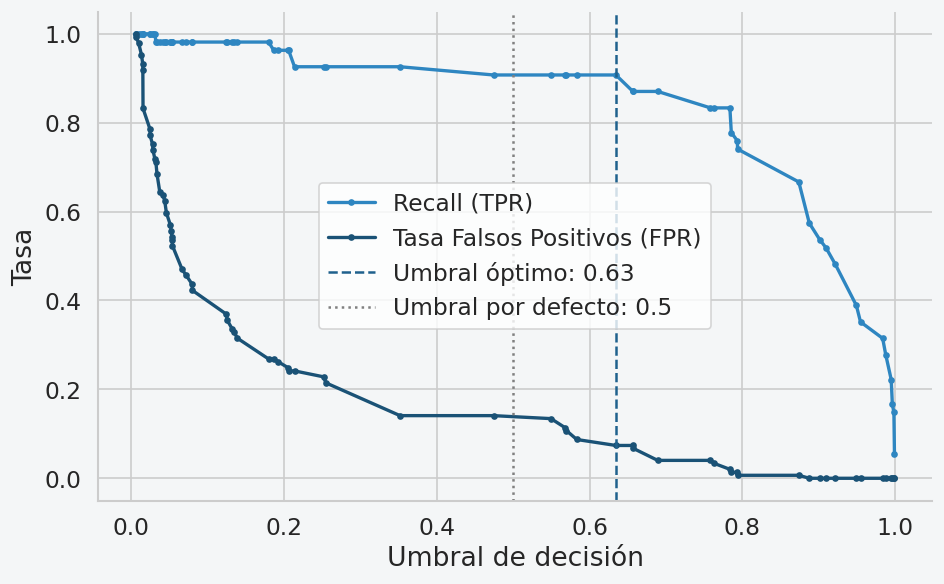

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_m2)
idx_optimo    = np.argmax(tpr - fpr)
umbral_optimo = thresholds[idx_optimo]

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('#f4f6f7')
fig.patch.set_facecolor('#f4f6f7')

ax.plot(thresholds, tpr, label='Recall (TPR)',                color='#2e86c1', marker='.', linewidth=2)
ax.plot(thresholds, fpr, label='Tasa Falsos Positivos (FPR)', color='#1a5276', marker='.', linewidth=2)
ax.axvline(x=umbral_optimo, color='#1f618d', linestyle='--',
           label=f'Umbral óptimo: {umbral_optimo:.2f}')
ax.axvline(x=0.5, color='gray', linestyle=':',
           label='Umbral por defecto: 0.5')

ax.set_xlabel('Umbral de decisión', fontsize=16)
ax.set_ylabel('Tasa', fontsize=16)
ax.set_title('Trade-off Recall / FPR según umbral\nRandom Forest', fontsize=18, fontweight='bold')
ax.tick_params(axis='both', labelsize=14)
ax.legend(fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()

**Interpretación de la curva ROC:**

**Árbol de Decisión (línea roja):** La curva está claramente por encima del clasificador aleatorio, lo que indica capacidad predictiva significativa. Su AUC sugiere que hay una alta probabilidad de que el modelo clasifique correctamente una instancia positiva elegida al azar por encima de una negativa. Sin embargo, su rendimiento es inferior al del Random Forest.

**Random Forest (línea azul):** La curva es la más cercana a la esquina superior izquierda (TPR = 1, FPR = 0), lo que indica un rendimiento casi ideal. Su AUC es excelente y significa que el modelo tiene una capacidad muy alta para distinguir entre las clases `high risk` y `low/mid risk`, superando claramente al Árbol de Decisión.

**Análisis de umbral:** el gráfico de la derecha muestra que bajando el umbral por debajo de 0.5 se incrementa el Recall de `high risk` a costa de aumentar los falsos positivos. En un contexto clínico donde no detectar un caso de alto riesgo es más grave que una alarma innecesaria, este trade-off puede ser conveniente y es una de las herramientas para mejorar el Recall sin cambiar el modelo.

### 7c. Evaluación final sobre test set

Habiendo seleccionado el **Random Forest** como modelo final en base a las métricas de validación cruzada, lo evaluamos sobre el conjunto de test. Este resultado es la estimación más honesta de cómo generalizaría el modelo con datos completamente nuevos.

In [ ]:
# @title
y_pred_m2 = (rf_model.predict_proba(X_test)[:, 1] >= umbral_optimo_m2).astype(int)

print('=== Evaluación final — Random Forest sobre test set ===')
print(f'Recall (high risk): {recall_score(y_test, y_pred_m2):.3f}')
print(f'F1-macro:           {f1_score(y_test, y_pred_m2, average="macro"):.3f}')
print(f'AUC-ROC:            {auc_m2_test:.3f}')
print()
print('Comparación con validación cruzada:')
print(f'Recall (CV):  {cv_recall_m2.mean():.3f} ± {cv_recall_m2.std():.3f}')
print(f'F1-macro (CV):{cv_f1_m2.mean():.3f} ± {cv_f1_m2.std():.3f}')
print(f'AUC-ROC (CV): {cv_auc_m2.mean():.3f} ± {cv_auc_m2.std():.3f}')

=== Evaluación final — Random Forest sobre test set ===
Recall (high risk): 0.907
F1-macro:           0.902
AUC-ROC:            0.964

Comparación con validación cruzada:
Recall (CV):  0.908 ± 0.032
F1-macro (CV):0.890 ± 0.030
AUC-ROC (CV): 0.963 ± 0.013


**Interpretación:**

Si los resultados sobre test son consistentes con los de validación cruzada, el modelo generaliza bien y no está sobreajustado. Una diferencia pequeña es esperable; una diferencia grande indicaría que el modelo memorizó el conjunto de entrenamiento.

### 7d. Conclusión: modelo elegido para fase operativa

Elegimos el **Random Forest** como modelo para una posible fase operativa por las siguientes razones:

1. Obtiene el mejor Recall de `high risk` en validación cruzada — en un contexto clínico, no detectar un caso de alto riesgo puede tener consecuencias graves.
2. Su AUC-ROC superior al Árbol de Decisión indica mayor capacidad para discriminar entre clases, y permite ajustar el umbral de decisión para maximizar aún más el Recall si fuera necesario.
3. Los resultados sobre test son consistentes con los de validación cruzada, lo que indica buena capacidad de generalización.
4. La importancia de atributos (`feature_importances_`) permite entender qué variables impulsan las predicciones — `BS` y `SystolicBP` lideran, confirmando el análisis del entregable anterior.

---
## 8. Trabajo futuro

1. **Métodos de ensamble avanzados:** explorar XGBoost y AdaBoost, que quedaron fuera del alcance de esta entrega. Estos métodos pueden capturar patrones aún más complejos y potencialmente superar al Random Forest.

2. **Optimización del umbral de decisión:** implementar una búsqueda sistemática del umbral óptimo para maximizar el Recall de `high risk` manteniendo una Precision clínicamente aceptable.

3. **Volver al target de 3 clases originales:** explorar si un modelo multiclase (low / mid / high risk) captura mejor la gradación del riesgo y aporta información clínica más útil.

4. **Optimización más exhaustiva:** ampliar el espacio de búsqueda con `RandomizedSearchCV` para explorar más combinaciones de hiperparámetros en menos tiempo.

5. **Incorporar features clínicas adicionales:** semana de gestación, historial de embarazos previos o resultados de análisis de orina podrían aportar información relevante para mejorar la predicción.